### Business Question: Which NYC taxi zones show the strongest taxi demand during peak, off-peak, and late-night periods, and which locations may need better taxi flow management?

Taxi demand matters for city planning because it affects mobility patterns, transport demand, service planning and congestion. An increase in taxi demand can cause an increase in congestion within pick-up and drop-off zones. A few select zones may need to introduce improved coordination of pick-up/drop off zones and kerbside passenger activity. Furthermore, late-night demand in hotspot locations can reveal areas where overnight taxi demand may continue to be concentrated in specific areas. Peak hour travel patterns can determine areas of strain and congestion within the transport network. City planners can utilise these insights to minimise congestion and assist the facilitation of passenger moveemnt.

The main audience of the analysis includes NYC city mobility planners, transport planners, taxi regulators, traffic control teams and transport data analysts. This project primarily focuses on NYC taxi zones, borough-based trends, pickup and drop-off areas and localised taxidemand. The analyses examines the January 2026 Yellow Taxi Trip records file. For this analysis, peak periods are classified as between 7:00-9:59AM AND 4:00-6:59PM because its the usual commuting hours in the morning and evening. Off-peak period is during the remaining day time and evening hours as when used for comparison. The late-night period in the dataset is between 12:00AM-5:59AM because it reflects late-night passenger demand from nightlife and airport travel. The results from the analysisn can support where areas in taxi pickup/drop-off management may need additional evaluation, as well as identifying zones which experience the highest demand. The results can also examine where late-night taxi demand is clustered. Consequently, the results can indicate locations where passenger flow may need improved organisation as well as determining where kerbside congestion may need better management. Taxi demand will be evaluated by comparing pick-up and drop-off counts across different zones and time periods. The results reflect yellow taxi demand only, as this project excludes public transport, ride-hailing, or other taxi service content.

### Installing Duckdb

In [1]:
!pip -q install duckdb pyarrow plotly

### 1.1 Data Loading

NYC TLC Taxi Trip Record Data: yellow_trip_data_2026-01.parquet

The yellow taxi dataset records all taxi trips with pick-up and drop-off times, location IDs, passenger count, and fare data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import duckdb

taxi_df = pd.read_parquet("yellow_tripdata_2026-01.parquet")


NYC Taxi Zones Dataset: taxi_zone_lookup (1).csv

The dataset stores key information such as location IDs, Borough's, Zone names and service zones enabling trip locations to successfully pair with transaprent geogrpahic labels.

In [3]:
zone_df = pd.read_csv("taxi_zone_lookup (1).csv")


### Display of First couple rows of for both datasets

Display of First couple rows of for NYC TLC Taxi Trip Record Data

In [4]:
taxi_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


Display of First couple rows of for NYC Taxi Zones Dataset

In [5]:
zone_df.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


### Dataset Shape for both Datasets

Display of Dataset Shape for NYC TLC Taxi Trip Record Data

In [6]:
print(f"Shape: {taxi_df.shape}\n")

Shape: (3724889, 20)



Display of Dataset Shape for NYC Taxi Zones Dataset

In [7]:
print(f"Shape: {zone_df.shape}\n")

Shape: (265, 4)



### Column names for both datasets

Columnn names for NYC TLC Taxi Trip Record Data

In [8]:
print(f"Columns: {taxi_df.columns}\n")

Columns: Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='object')



Columnn names for NYC Taxi Zones Dataset

In [9]:
print(f"Columns: {zone_df.columns}\n")

Columns: Index(['LocationID', 'Borough', 'Zone', 'service_zone'], dtype='object')



### Column name datatypes for both datasets


Columnn name datatypes for NYC TLC Taxi Trip Record Data

In [10]:
print(f"Data Types: {taxi_df.dtypes}")

Data Types: VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object



Columnn name datatypes for NYC Taxi Zones Dataset

In [11]:
print(f"Data Types: {zone_df.dtypes}")

Data Types: LocationID       int64
Borough         object
Zone            object
service_zone    object
dtype: object


### Sample Records for both datasets

Sample Records for NYC TLC Taxi Trip Record Data

In [12]:
taxi_df_sample = taxi_df.sample(n=10)
print(taxi_df_sample)

         VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
2973824         2  2026-01-12 09:14:48   2026-01-12 09:19:59              NaN   
3692276         2  2026-01-31 13:54:13   2026-01-31 14:07:39              NaN   
2467290         2  2026-01-30 08:37:13   2026-01-30 09:20:09              1.0   
2487838         2  2026-01-30 14:20:54   2026-01-30 14:36:02              1.0   
925600          2  2026-01-12 09:19:15   2026-01-12 09:33:44              1.0   
2040888         2  2026-01-24 02:32:18   2026-01-24 02:49:47              1.0   
6441            2  2026-01-01 01:26:03   2026-01-01 01:28:46              1.0   
594676          1  2026-01-08 16:58:26   2026-01-08 17:07:37              1.0   
3661236         1  2026-01-30 22:41:42   2026-01-30 22:56:12              NaN   
1120379         1  2026-01-14 12:42:37   2026-01-14 12:50:50              1.0   

         trip_distance  RatecodeID store_and_fwd_flag  PULocationID  \
2973824           1.02         NaN   

Sample Records for NYC Taxi Zones Dataset

In [13]:
zone_df_sample = zone_df.sample(n=10)
print(zone_df_sample)

     LocationID        Borough                                 Zone  \
56           57         Queens                               Corona   
191         192         Queens                      Queensboro Hill   
41           42      Manhattan                 Central Harlem North   
1             2         Queens                          Jamaica Bay   
110         111       Brooklyn                  Green-Wood Cemetery   
43           44  Staten Island               Charleston/Tottenville   
224         225       Brooklyn                   Stuyvesant Heights   
26           27         Queens  Breezy Point/Fort Tilden/Riis Beach   
93           94          Bronx                        Fordham South   
183         184          Bronx                      Pelham Bay Park   

    service_zone  
56     Boro Zone  
191    Boro Zone  
41     Boro Zone  
1      Boro Zone  
110    Boro Zone  
43     Boro Zone  
224    Boro Zone  
26     Boro Zone  
93     Boro Zone  
183    Boro Zone  


### Governance control: data minimisation

Data Minimisation for  NYC TLC Taxi Trip Record Data

The raw taxi dataset contains columns that aren't necessary for the analysis. By reducing the amount of columsn to only 7, we can, develop the analysis into a more reliable and consistent structure which will output results which will directly answer the business question. These remaining colummns were kept because they enable data to be structured via time period, examined by taxi zone and assessed for trip basic trip behaviour. The NYC Taxi Zones Dataset is already prepared as a small lookup table, therefore, no minimisation is required.

In [14]:
print(f"Shape: {taxi_df.shape}\n")

columns_to_keep = ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'fare_amount', 'passenger_count']

smaller_taxi_df = taxi_df[columns_to_keep].copy()

print(f"Shape: {smaller_taxi_df.shape}\n")
print()
print()

print(f"Columns: {smaller_taxi_df.columns}\n")

Shape: (3724889, 20)

Shape: (3724889, 7)



Columns: Index(['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID',
       'DOLocationID', 'trip_distance', 'fare_amount', 'passenger_count'],
      dtype='object')



### 1.2 Data Quality

### Missing Values

Identifying missing values in the newly created smaller NYC TLC Taxi Trip Record Data dataframe.

Inside the output the columns which contained missing values was passenger_count. The number of missing values passenger_count has stored is 1088058 values. This approximates to %29.21 of the passenger_count column missing values. Because passenger_count doesn't affect the measure of demand or contribute to the business question, there is no reason to remove it currently though values are missing. Due to pickup and drop-off times and location IDs are filled, the primary demand analysis can proceed.

In [15]:
print(f"Missing Values per Column: {smaller_taxi_df.isnull().sum()}\n")
print(f"Percentage of Missing Values per Column: {(smaller_taxi_df.isnull().sum() / len(smaller_taxi_df)) * 100}\n")

Missing Values per Column: tpep_pickup_datetime           0
tpep_dropoff_datetime          0
PULocationID                   0
DOLocationID                   0
trip_distance                  0
fare_amount                    0
passenger_count          1088058
dtype: int64

Percentage of Missing Values per Column: tpep_pickup_datetime      0.000000
tpep_dropoff_datetime     0.000000
PULocationID              0.000000
DOLocationID              0.000000
trip_distance             0.000000
fare_amount               0.000000
passenger_count          29.210481
dtype: float64



Identifying missing values in the NYC Taxi Zones Dataset

Within the Taxi Zone dataset, the output displays LocationID having 0 missing values, Borough containing 1 missing value, Zone containing 1 missing value and service_zone containing 2 missing values. This showcases that minimum number of values are missing in each column, and are primarily located in the label columns not in LocationID. During data cleaning the rows will be scrutinised to choose either to discard them or give them a label as unknown. Data cleaning will ensure the missing values won't interfere with connecting PULocationID and DOLocationID. Due to LocationID not causing any value irregularities, the lookup table is still mostly accessible.

In [16]:
print(f"Missing Values per Column: {zone_df.isnull().sum()}\n")
print(f"Percentage of Missing Values per Column: {(zone_df.isnull().sum() / len(zone_df)) * 100}\n")

Missing Values per Column: LocationID      0
Borough         1
Zone            1
service_zone    2
dtype: int64

Percentage of Missing Values per Column: LocationID      0.000000
Borough         0.377358
Zone            0.377358
service_zone    0.754717
dtype: float64



### Duplicate Rows

There are 539 duplicate rows in the smaller NYC TLC Taxi Trip Record Data dataframe

Calculating the total amount of duplicate entries inside the smaller NYC TLC Taxi Trip Record Data dataframe

The smaller taxi data frame contains duplicate rows. 539 duplicate rows are contained in the smaller taxi dataframe. During data, cleaning duplicate rows will be discarded from the smaller taxi datafrmae as it may overcount trips. Fuethermore, the business question must utilise trip counts via zone and time period. Duplicate taxi records can overstate demand levels and exacerbate activity in various zones. These duplicat rows are also extracted from the smaller dataframe.

In [17]:
print(f"How many Duplicate Rows Exist: {smaller_taxi_df.duplicated().sum()}\n")

How many Duplicate Rows Exist: 539



Calculating the total amount of duplicate entries inside the  NYC Taxi Zones Dataset.

The Taxi Zone dataset contains 0 duplicate rows, as well as none of the rows were impacted via duplication. The Taxi Zones dataset is referred to as s lookup table, therefore all zone reocords must be distinct from each other. Due to 0 duplicate rows being output, it can assist with pickup/drop-off location IDs excluding iterative zone matches inflating demand counts.

In [18]:
print(f"How many Duplicate Rows Exist: {zone_df.duplicated().sum()}\n")

How many Duplicate Rows Exist: 0



Assessing duplicates for LocationID within the NYC Taxi Zones Dataset.

The column LocationID contains 0 duplicate records and values. Consequentially, no cleaning action is necessary for the LocationID column. LocationID is the primary key integrated to connect the Taxi Zones dataset with the PULocationID and DOLocationID. If the column contained duplicates, then the join would corrupt the zone records and the whole analysis.

In [19]:
duplicate_count = zone_df.duplicated(subset=['LocationID']).sum()
print(f"Duplicate count for LocationID: {duplicate_count}")

Duplicate count for LocationID: 0


###  Invalid Timestamps

Assessing pickup and drop-off timestamps inside the smaller NYC TLC Taxi Trip Record Data dataframe

Invalid pickup a,d dropoff timestamps aimed to identify dates which are fundmamentally incompatable with the analysis time period which is January. The output for timestamps outside of January 2026 depicts dates which are not within the time period of the dataset. Drop-off before pickup assesses the date before picking up a person. Extended trip durations assesses the time it takes for a trip to complete its course of action. The invalid pickup tinestamps recorded 0 invalid timestamps, invalid dropoff recorded 0 invalid dropoffs, timestamps external of January 2026 recorded 7 timestamps, drop-off timestamps before pick-up only logged 1 timestamp before pickup and, the extended trip duration reoced 1309 hours. During data cleaning, valid datetime converted columns will be maintained, rows outside of January 2026 will either be flagged or discarded, drop-off before pickup rows will either be flagged or discarded, and the potnetial removal of extneded trips, upon the rule defined in the cleaning process. The overall analysis integrates peak period, off-peak period, late-night period and the January 2026 boundary in order to answer the business question. Any timestamps that extend or are un-aligned with the scope and objectives of the analysis must not be used or else it can exacerbate trends in demand. The 6-hour threshold was created to flag any suspect taxi trips which can result in distorted tracking.

In [20]:
smaller_taxi_df['tpep_pickup_datetime'] = pd.to_datetime(smaller_taxi_df[('tpep_pickup_datetime')], errors='coerce')
smaller_taxi_df['tpep_dropoff_datetime'] = pd.to_datetime(smaller_taxi_df[('tpep_dropoff_datetime')], errors='coerce')

invalid_pickups = smaller_taxi_df[smaller_taxi_df['tpep_pickup_datetime'].isna()]
invalid_dropoffs = smaller_taxi_df[smaller_taxi_df['tpep_dropoff_datetime'].isna()]

print(f"Invalid pickup timestamps: {len(invalid_pickups)}")
print(f"Invalid dropoff timestamps: {len(invalid_dropoffs)}")

start_date = "2026-01-01"
end_date = "2026-02-01"

outside_month = ((smaller_taxi_df['tpep_pickup_datetime'] < start_date) | (smaller_taxi_df['tpep_pickup_datetime'] >= end_date))
outside_month_timestamp_count = outside_month.sum()

print(f"Timestamps outside of January 2026: {outside_month_timestamp_count}")

drop_off_datetime = pd.to_datetime(smaller_taxi_df[('tpep_dropoff_datetime')], errors='coerce')
pickup_datetime = pd.to_datetime(smaller_taxi_df[('tpep_pickup_datetime')], errors='coerce')

dropoff_before_pickup = (smaller_taxi_df['tpep_dropoff_datetime'] < smaller_taxi_df['tpep_pickup_datetime'])
dropoff_before_pickup_count = dropoff_before_pickup.sum()

print(f'Drop-off timestamps before pickup timestamps: {dropoff_before_pickup_count}')

trip_duration = (smaller_taxi_df['tpep_dropoff_datetime'] - smaller_taxi_df['tpep_pickup_datetime'])
trip_duration_in_hours = trip_duration.dt.total_seconds() / 3600
trip_threshold = 6
extended_trip_duration = trip_duration_in_hours > trip_threshold
extended_trip_duration_count = extended_trip_duration.sum()

print(f"Extended trip durations: {extended_trip_duration_count}")


Invalid pickup timestamps: 0
Invalid dropoff timestamps: 0
Timestamps outside of January 2026: 7
Drop-off timestamps before pickup timestamps: 1
Extended trip durations: 1309


### Negative Fares

Examining negative fares associated with the smaller NYC TLC Taxi Trip Record Data dataframe

The check assessed fare_amount records which are under zero. 39,463 negative fare records were affected. During data cleaning, the negative fair records will either be flagged or discarded. This is appropriate to ensure that the demand count in the analysis isn't impacted by refunds, transactions or insufficient fare details. Invalid fare records can also convolute the reliability of the whole dataset.

In [21]:
count_of_negative_fare_amount = (smaller_taxi_df['fare_amount'] < 0).sum()

print(f"Number of negative fares: {count_of_negative_fare_amount}")

Number of negative fares: 39463


### Impossible trip distances

Assessing the impossible trip distances for the smaller NYC TLC Taxi Trip Record Data dataframe

The output of the code displays that 125,849n records were flagged. During the cleaning process these flagged records will either be discarded or flagged. Furthermore, invalid distances may instiage cancelled trips, logging issues and disruption of trip tracking.

In [22]:
zero_or_impossible_distances = smaller_taxi_df[smaller_taxi_df['trip_distance'] <= 0]
missing_distances = smaller_taxi_df[smaller_taxi_df['trip_distance'].isna()]
invalid_outliers = smaller_taxi_df[smaller_taxi_df['trip_distance'] > 1000]

is_invalid = (smaller_taxi_df['trip_distance'] <= 0) | smaller_taxi_df['trip_distance'].isna() | (smaller_taxi_df['trip_distance'] > 1000)
is_invalid_records = smaller_taxi_df[is_invalid]

is_invalid_records_count = len(is_invalid_records)
print("Invalid records: ", is_invalid_records_count)
is_invalid_records.head()


Invalid records:  125849


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,passenger_count
118,2026-01-01 00:21:36,2026-01-01 00:22:52,239,43,0.0,3.0,1.0
329,2026-01-01 00:11:22,2026-01-01 00:34:04,43,170,0.0,18.4,1.0
330,2026-01-01 00:54:54,2026-01-01 01:09:08,161,137,0.0,12.8,1.0
360,2026-01-01 00:32:10,2026-01-01 00:32:14,162,162,0.0,50.0,4.0
634,2026-01-01 00:45:48,2026-01-01 00:45:54,261,261,0.0,50.0,1.0


### Invalid Passenger Counts

Identify and assess the invalid passenger counts in the smaller NYC TLC Taxi Trip Record Data dataframe

The output displayed two issues: missing passenger_count values and invalid passenger counts incuding 0 or values extending beyond average taxi capacity. From the output, missing passenger and invalid passenger quantify rows. During data cleaning, the passenger counts will either be discarded, flagged or could be kept within the dataset if it isn't vital for the analysis. Passenger count only examines trip validity, therefore it should only be managed but doesn't negatively affect the analysis.

In [23]:
missing_passenger_count = smaller_taxi_df['passenger_count'].isna().sum()

print(f"Missing passenger count: {missing_passenger_count}")

invalid_passenger_count = ((smaller_taxi_df['passenger_count'] <= 0) | (smaller_taxi_df['passenger_count'] > 6)).sum()

print(f"Invalid passenger count: {invalid_passenger_count}")


Missing passenger count: 1088058
Invalid passenger count: 14794


Missing Locations

Examine missing PULocationID and DOLocationID values in  the smaller NYC TLC Taxi Trip Record Data dataframe

The taxi trip dataset has no missing PULocationID and no missing DOLocation ID. No rows were affected for either column. No rows will need to be discarded for any lost location IDs. After connecting with the Taxi Zones table, it should still be possible to verify if all IDs correspond with a zone name. Location IDs are necessary as the business question requires the comparison time period and demand by taxi zone.

In [24]:
missing_PULocationID_values_count = smaller_taxi_df['PULocationID'].isna().sum()

print(f"Missing PULocationID values: {missing_PULocationID_values_count}")

missing_DOLocationID_values_count = smaller_taxi_df['DOLocationID'].isna().sum()

print(f"Missing DOCLocationID values: {missing_DOLocationID_values_count}")

Missing PULocationID values: 0
Missing DOCLocationID values: 0


Examining missing Borough and Zone values inside the NYC Taxi Zones Dataset

The Taxi Zones lookup table contains missing values in Borough and Zone. Both columns contain one missing row. During data cleaning, the lookup rows will either be discarded if they don't correspond with valid taxi trip records, or they will be labelled as "unknown" if the decision is to keep it. The Taxi Zones dataset is necessary for PULocationID and DOLocationID to translate into borouh and zone names. Missing borough and zone names can impact spatial-reasoning.

In [25]:
missing_Borough_values_count = zone_df['Borough'].isna().sum()

print(f"Missing Borough values: {missing_Borough_values_count}")

missing_Zone_values_count = zone_df['Zone'].isna().sum()

print(f"Missing Zone values: {missing_Zone_values_count}")

Missing Borough values: 1
Missing Zone values: 1


### Extreme outliers

Determing the extreme outliers within the smaller NYC TLC Taxi Trip Record Data dataframe

The IQR method was implemented to flag abnormal values whether high or low inside the columns trip_distance and fare_amount. The output depicts 56,095 extreme outliers for fare_amount and 19,302 extreme outliers for trip_distance. Data cleaning will handle the outliers carefully as a select few trips with high fares or long distances may be authentic. Cleaning can involve the discarding of impossible values and plausible but uncommon values can be maintained or flagged instead of be discarded. CLeaning will depend on whether the value is clearly unreliable or if it's plausible. Extreme fares and distances can disrupt summary statistics and visualisations, though, outliers aren't always mistakes.

In [26]:
Q1 = smaller_taxi_df['trip_distance'].quantile(0.25)
Q3 = smaller_taxi_df['trip_distance'].quantile(0.75)
IQR = Q3 - Q1

lower_extreme = Q1 - 3.0 * IQR
upper_extreme = Q3 + 3.0 * IQR

extreme_outliers = smaller_taxi_df[(smaller_taxi_df['trip_distance'] < lower_extreme) | (smaller_taxi_df['trip_distance'] > upper_extreme)]
extreme_outliers_count = len(extreme_outliers)

Q1 = smaller_taxi_df['fare_amount'].quantile(0.25)
Q3 = smaller_taxi_df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_extreme = Q1 - 3.0 * IQR
upper_extreme = Q3 + 3.0 * IQR

extreme_outliers_second = smaller_taxi_df[(smaller_taxi_df['fare_amount'] < lower_extreme) | (smaller_taxi_df['fare_amount'] > upper_extreme)]
extreme_outliers_second_count = len(extreme_outliers_second)

print("Extreme Outliers for Fare Amount: ", extreme_outliers_second_count)
display(extreme_outliers_second.head())


print("Extreme Outliers for Trip Distances: ", extreme_outliers_count)
display(extreme_outliers.head())

Extreme Outliers for Fare Amount:  56095


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,passenger_count
39,2026-01-01 00:49:04,2026-01-01 01:36:01,140,265,19.10,80.0,1.0
355,2026-01-01 00:33:40,2026-01-01 00:39:20,249,249,0.40,100.0,1.0
404,2026-01-01 00:31:18,2026-01-01 00:50:00,48,265,11.49,135.0,4.0
471,2026-01-01 00:58:31,2026-01-01 02:09:31,79,256,18.69,85.6,1.0
591,2026-01-01 00:20:19,2026-01-01 01:16:02,170,14,20.01,83.5,1.0


Extreme Outliers for Trip Distances:  199302


,tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,trip_distance,fare_amount,passenger_count
39,2026-01-01 00:49:04,2026-01-01 01:36:01,140,265,19.10,80.0,1.0
51,2026-01-01 00:01:27,2026-01-01 00:44:30,132,246,18.47,70.0,1.0
59,2026-01-01 00:22:21,2026-01-01 01:00:28,138,14,19.90,74.4,1.0
66,2026-01-01 00:29:56,2026-01-01 00:53:41,132,255,15.42,56.9,1.0
149,2026-01-01 00:00:22,2026-01-01 00:27:41,132,75,19.15,70.0,2.0


### Inconsistent Categories

Determining the amount of inconsistent categories in the service_zone column.

The service_zone column contains categories which include: Boro Zone, Yellow Zone, Airports, NaN and EWR. The rows in Boro Zone were most affect, however it also struck Yellow Zone and  and a portion in Airportsn EWR or missing. The missing service_zone values will be managed durign data cleaning, but right now the category labels are accurate and reliable. Furthermore, service_zone assisrs in determining taxi zone type, though the analysis primarily relies more on Borough, Zone and LocationID

In [27]:

zone_df['service_zone'].value_counts(dropna=False)

,count
service_zone,
Boro Zone,205
Yellow Zone,55
Airports,2
NaN,2
EWR,1


### 1.3 Data Data Cleaning

### Creating cleaned copies of the dataframes

Creating a cleaned dataframe version for the smaller_taxi_df dataframe which will be cleaned.

In [28]:
cleaned_taxi_df = smaller_taxi_df.copy()

Creating a cleaned dataframe version for the zone_df dataframe which will be cleaned.

In [29]:
cleaned_zone_df = zone_df.copy()

### Starting row counts

Displaying row counts before cleaning for the cleaned_taxi_df

In [30]:
cleaned_taxi_df.shape[0]

3724889

Displaying row counts before cleaning for the  zone_df dataframe

In [31]:
cleaned_zone_df.shape[0]

265

### Remove Duplicates

Removing duplicates inside the cleaned_taxi_df dataframe

In [32]:
print(f"How many Duplicate Rows Exist: {cleaned_taxi_df.duplicated().sum()}\n")

How many Duplicate Rows Exist: 539



In [33]:
cleaned_taxi_df = cleaned_taxi_df.drop_duplicates()

In [34]:
counted_duplicates = cleaned_taxi_df.duplicated().sum()

print(f"Number of Duplicate Rows: {counted_duplicates}")

Number of Duplicate Rows: 0


In [35]:
cleaned_taxi_df.shape[0]

3724350

### Removing Invalid Timestamps

Removing Invalid Timestamps from the  cleaned_taxi_df dataframe

In [36]:
cleaned_taxi_df['tpep_pickup_datetime'] = pd.to_datetime(cleaned_taxi_df['tpep_pickup_datetime'], errors="coerce")
cleaned_taxi_df['tpep_dropoff_datetime'] = pd.to_datetime(cleaned_taxi_df['tpep_dropoff_datetime'], errors="coerce")

cleaned_taxi_df = cleaned_taxi_df[
    cleaned_taxi_df['tpep_pickup_datetime'].notna() &
    cleaned_taxi_df['tpep_dropoff_datetime'].notna()
]

start_date = "2026-01-01"
end_date = "2026-02-01"

cleaned_taxi_df = cleaned_taxi_df[
    (cleaned_taxi_df['tpep_pickup_datetime'] >= start_date) &
    (cleaned_taxi_df['tpep_pickup_datetime'] < end_date)
]

cleaned_taxi_df = cleaned_taxi_df[cleaned_taxi_df['tpep_dropoff_datetime'] >= cleaned_taxi_df['tpep_pickup_datetime']]


trip_duration = cleaned_taxi_df['tpep_dropoff_datetime'] - cleaned_taxi_df['tpep_pickup_datetime']
trip_duration_in_hours = trip_duration.dt.total_seconds() / 3600

cleaned_taxi_df = cleaned_taxi_df[trip_duration_in_hours <= 6]

print(f"The rows after removing trips extended past 6 hours: {len(cleaned_taxi_df)}")

The rows after removing trips extended past 6 hours: 3723037


### Clean Impossible Trip distances

Remove any trip distance values that are unusually high or equal to or below zero

In [37]:
print(f"Trip distance rows before cleaning: {len(cleaned_taxi_df)}")

zero_or_impossible_distances = cleaned_taxi_df[cleaned_taxi_df['trip_distance'] <= 0]
missing_distances = cleaned_taxi_df[cleaned_taxi_df['trip_distance'].isna()]
invalid_outliers = cleaned_taxi_df[cleaned_taxi_df['trip_distance'] > 1000]


is_invalid = (cleaned_taxi_df['trip_distance'] <= 0) | cleaned_taxi_df['trip_distance'].isna() | (cleaned_taxi_df['trip_distance'] > 1000)
is_invalid_records = cleaned_taxi_df[is_invalid]

is_invalid_records_count = len(is_invalid_records)
print("Invalid records: ", is_invalid_records_count)
cleaned_taxi_df = cleaned_taxi_df[~is_invalid]

print(f"Trip distance rows after cleaning: {len(cleaned_taxi_df)}")

Trip distance rows before cleaning: 3723037
Invalid records:  125540
Trip distance rows after cleaning: 3597497


### Clean Negative Fares

Remove fares that are less than zero

In [38]:
print(f"Rows before discarding the negative fares: {len(cleaned_taxi_df)}")

count_of_negative_fare_amount = (cleaned_taxi_df['fare_amount'] < 0).sum()

negative_fares = cleaned_taxi_df["fare_amount"] < 0
cleaned_taxi_df = cleaned_taxi_df[~negative_fares]

print(f"Number of negative fares removed: {count_of_negative_fare_amount}")
print(f"Rows after discarding the negative fares: {len(cleaned_taxi_df)}")

Rows before discarding the negative fares: 3597497
Number of negative fares removed: 36703
Rows after discarding the negative fares: 3560794


### Managing Passenger Count

Manage the transparent invalid passenger counts

In [39]:
missing_passenger_count = cleaned_taxi_df['passenger_count'].isna().sum()

print(f"Missing passenger count: {missing_passenger_count}")

invalid_passenger_count = (cleaned_taxi_df['passenger_count'] <= 0) | (cleaned_taxi_df['passenger_count'] > 6)

invalid_passenger_count_total = invalid_passenger_count.sum()

cleaned_taxi_df.loc[invalid_passenger_count, 'passenger_count'] = None

print(f"Invalid passenger count: {invalid_passenger_count_total}")
print(f"Missing passenger count after cleaning: {cleaned_taxi_df['passenger_count'].isna().sum()}")
print(f" Rows after passenger count cleaning: {len(cleaned_taxi_df)}")

Missing passenger count: 995184
Invalid passenger count: 14234
Missing passenger count after cleaning: 1009418
 Rows after passenger count cleaning: 3560794


### Cleaning the Taxi Zones dataset

The dataset Iaxi Zone lookup with the dataframe cleaned_zone_nf are to be carefully cleaned for more efficient and reliable use of the data.

In [40]:

cleaned_zone_df['service_zone'].value_counts(dropna=False)

missing_service_zones = cleaned_zone_df[cleaned_zone_df['service_zone'].isna()]

cleaned_zone_df['service_zone'] = cleaned_zone_df['service_zone'].fillna('Unknown')
cleaned_zone_df["Borough"] = cleaned_zone_df["Borough"].fillna('Unknown')
cleaned_zone_df['Zone'] = cleaned_zone_df['Zone'].fillna('Unknown')

missing_values_service_zone = cleaned_zone_df['service_zone'].isna().sum()
missing_values_borough = cleaned_zone_df['Borough'].isna().sum()
missing_values_zone = cleaned_zone_df['Zone'].isna().sum()

missing_values_service_zone = cleaned_zone_df['service_zone'].isna().sum()
print(f"MIssing values for service_zone: {missing_values_service_zone}")
print(f"MIssing values for Borough: {missing_values_borough}")
print(f"MIssing values for Zone: {missing_values_zone}")
print(f"Rows after cleaning: {len(cleaned_zone_df)}")

cleaned_zone_df['service_zone'].value_counts(dropna=False)

MIssing values for service_zone: 0
MIssing values for Borough: 0
MIssing values for Zone: 0
Rows after cleaning: 265


,count
service_zone,
Boro Zone,205
Yellow Zone,55
Airports,2
Unknown,2
EWR,1


### Cleaning Summary

| Cleaning issue | Rows affected | Decision | Reason |
|---|---:|---|---|
| Duplicate taxi rows | 539 | Discarded | Prevents double-counting taxi demand by zone and time period. |
| Invalid timestamps | 1,313 | Discarded | Protects peak, off-peak, and late-night time-period grouping. |
| Impossible trip distances | 125,540 | Discarded | Removes zero, missing, or unrealistic trip-distance records. |
| Negative fares | 36,703 | Discarded | Removes refund, reversal, or invalid fare records. |
| Invalid passenger counts | 14,234 | Set to missing | Keeps useful trip records while removing unreliable passenger-count values. |
| Missing Taxi Zone labels | Small number | Subsitiuted with `"Unknown"` | Keeps `LocationID` usable for joining while avoiding blank zone labels. |

### Rechecking cleaned data frames

Rechecking the cleaned_taxi_df dataframe

In [41]:
cleaned_taxi_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3560794 entries, 0 to 3724888
Data columns (total 7 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   PULocationID           int32         
 3   DOLocationID           int32         
 4   trip_distance          float64       
 5   fare_amount            float64       
 6   passenger_count        float64       
dtypes: datetime64[us](2), float64(3), int32(2)
memory usage: 190.2 MB


Rechecking the cleaned_zone_df dataframe

In [42]:
cleaned_zone_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   LocationID    265 non-null    int64 
 1   Borough       265 non-null    object
 2   Zone          265 non-null    object
 3   service_zone  265 non-null    object
dtypes: int64(1), object(3)
memory usage: 8.4+ KB


### 1.4 Transformation

Creating the pickup_hour column

In [43]:
cleaned_taxi_df['pickup_hour'] = cleaned_taxi_df['tpep_pickup_datetime'].dt.hour

cleaned_taxi_df[["tpep_pickup_datetime", "pickup_hour"]].head()

,tpep_pickup_datetime,pickup_hour
0,2026-01-01 00:54:04,0
1,2026-01-01 00:34:04,0
2,2026-01-01 00:57:06,0
3,2026-01-01 00:15:22,0
4,2026-01-01 00:27:13,0


Creating the pickup_date column

In [44]:
cleaned_taxi_df['pickup_date'] = cleaned_taxi_df['tpep_pickup_datetime'].dt.date

cleaned_taxi_df[["tpep_pickup_datetime", "pickup_date"]].head()

,tpep_pickup_datetime,pickup_date
0,2026-01-01 00:54:04,2026-01-01
1,2026-01-01 00:34:04,2026-01-01
2,2026-01-01 00:57:06,2026-01-01
3,2026-01-01 00:15:22,2026-01-01
4,2026-01-01 00:27:13,2026-01-01


Creating the day_of_the_week column

In [45]:
cleaned_taxi_df['day_of_week'] = cleaned_taxi_df['tpep_pickup_datetime'].dt.day_name()

cleaned_taxi_df[["tpep_pickup_datetime", "day_of_week"]].head()

,tpep_pickup_datetime,day_of_week
0,2026-01-01 00:54:04,Thursday
1,2026-01-01 00:34:04,Thursday
2,2026-01-01 00:57:06,Thursday
3,2026-01-01 00:15:22,Thursday
4,2026-01-01 00:27:13,Thursday


Creating the is_weekend column

In [46]:
cleaned_taxi_df['is_weekend'] = cleaned_taxi_df['day_of_week'].isin(['Saturday', 'Sunday'])

cleaned_taxi_df[["day_of_week", "is_weekend"]].head()

,day_of_week,is_weekend
0,Thursday,False
1,Thursday,False
2,Thursday,False
3,Thursday,False
4,Thursday,False


Creating the time_period column

In [47]:
cleaned_taxi_df['time_period'] = "off-peak"

cleaned_taxi_df.loc[cleaned_taxi_df['pickup_hour'].isin([0, 1, 2, 3, 4, 5]), "time_period"] = 'late-night'
cleaned_taxi_df.loc[cleaned_taxi_df['pickup_hour'].isin([7, 8, 9, 16, 17, 18]), "time_period"] = 'peak'

cleaned_taxi_df[["pickup_hour", "time_period"]].head()


,pickup_hour,time_period
0,0,late-night
1,0,late-night
2,0,late-night
3,0,late-night
4,0,late-night


Creating the trip_duration_minutes column

In [48]:
cleaned_taxi_df["trip_duration_minutes"] = (cleaned_taxi_df["tpep_dropoff_datetime"] - cleaned_taxi_df["tpep_pickup_datetime"]).dt.total_seconds() / 60

cleaned_taxi_df[["tpep_pickup_datetime", "tpep_dropoff_datetime", "trip_duration_minutes"]].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,trip_duration_minutes
0,2026-01-01 00:54:04,2026-01-01 00:59:37,5.550000
1,2026-01-01 00:34:04,2026-01-01 00:39:47,5.716667
2,2026-01-01 00:57:06,2026-01-01 01:05:59,8.883333
3,2026-01-01 00:15:22,2026-01-01 00:58:10,42.800000
4,2026-01-01 00:27:13,2026-01-01 00:40:43,13.500000


Creating the distance_category column

In [49]:
cleaned_taxi_df["distance_category"] = pd.cut(cleaned_taxi_df["trip_distance"], bins=[0, 2, 10, np.inf], labels=["short", "medium", "long"], include_lowest=True)

cleaned_taxi_df[['trip_distance', "distance_category"]].head()
cleaned_taxi_df["distance_category"].value_counts()

,count
distance_category,
short,1877853
medium,1408987
long,273954


### Creating pickup zone labels

In [50]:
pick_up_zone_look_up = cleaned_zone_df.rename(
    columns={
        "LocationID": "PULocationID",
        "Borough": "pickup_borough",
        "Zone": "pickup_zone",
        "service_zone": "pickup_service_zone"
    }
)

### Merged Taxi Data and Taxi Zone data

In [51]:
combined_taxi_df = cleaned_taxi_df.merge(
    pick_up_zone_look_up[["PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone"]],
    on="PULocationID",
    how="left"
)

### Constructing drop-off fields

In [52]:
dropoff_zone_lookup = cleaned_zone_df.rename(
    columns={
        "LocationID": "DOLocationID",
        "Borough": "dropoff_borough",
        "Zone": "dropoff_zone",
        "service_zone": "dropoff_service_zone"
    }
)

### Merge Drop-off second join with already joined taxi dataframe through DOLocationID

In [53]:
combined_taxi_df = combined_taxi_df.merge(
    dropoff_zone_lookup[['DOLocationID', "dropoff_borough", "dropoff_zone", "dropoff_service_zone"]],
    on="DOLocationID",
    how="left"
)

### Assessing the result

In [54]:



combined_taxi_df[[
    "pickup_borough", "pickup_zone", "dropoff_borough", "dropoff_zone"
]].isna().sum()

print(combined_taxi_df.shape)

combined_taxi_df[[
    "PULocationID", "pickup_borough", "pickup_zone", "DOLocationID", "dropoff_borough", "dropoff_zone", "time_period"
]].head()



(3560794, 20)


,PULocationID,pickup_borough,pickup_zone,DOLocationID,dropoff_borough,dropoff_zone,time_period
0,239,Manhattan,Upper West Side South,238,Manhattan,Upper West Side North,late-night
1,163,Manhattan,Midtown North,162,Manhattan,Midtown East,late-night
2,43,Manhattan,Central Park,237,Manhattan,Upper East Side South,late-night
3,142,Manhattan,Lincoln Square East,209,Manhattan,Seaport,late-night
4,88,Manhattan,Financial District South,144,Manhattan,Little Italy/NoLiTa,late-night


Checking if there are any missing values

In [55]:

combined_taxi_df[[
    "pickup_borough", "pickup_zone", "dropoff_borough", "dropoff_zone"
]].isna().sum()

,0
pickup_borough,0
pickup_zone,0
dropoff_borough,0
dropoff_zone,0


### 1.5 Store and Query Data with SQL

### SQL table for combined_taxi_df

In [56]:
con = duckdb.connect(database=":memory:")

con.register("taxi_trips", combined_taxi_df)
con.register("taxi_zones", cleaned_zone_df)

con.execute("""
SELECT pickup_hour, time_period, pickup_borough, pickup_zone, dropoff_borough, dropoff_zone, trip_distance
FROM taxi_trips
LIMIT 5
""").df()

,pickup_hour,time_period,pickup_borough,pickup_zone,dropoff_borough,dropoff_zone,trip_distance
0,0,late-night,Manhattan,Upper West Side South,Manhattan,Upper West Side North,0.97
1,0,late-night,Manhattan,Midtown North,Manhattan,Midtown East,0.90
2,0,late-night,Manhattan,Central Park,Manhattan,Upper East Side South,1.40
3,0,late-night,Manhattan,Lincoln Square East,Manhattan,Seaport,5.58
4,0,late-night,Manhattan,Financial District South,Manhattan,Little Italy/NoLiTa,2.16


### SQL Query 1: Trips by time period

In [84]:
con.execute("""
SELECT time_period, COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY time_period
ORDER BY trip_count DESC
LIMIT 5;
""").df()

,time_period,trip_count
0,off-peak,2151252
1,peak,1074477
2,late-night,335065


### SQL Query 2: Top Pickup Zones Overall

In [58]:
top_pickup_zones = con.execute("""
SELECT COUNT(*) AS trip_count, pickup_borough, pickup_zone
FROM taxi_trips
GROUP BY pickup_borough, pickup_zone
ORDER BY trip_count DESC
LIMIT 10;
""").df()

### SQL Query 3: Borough Demand by time period

In [79]:
borough_time_period_demand_df = con.execute("""
SELECT COUNT(*) AS trip_count, pickup_borough, time_period
FROM taxi_trips
GROUP BY pickup_borough, time_period
ORDER BY pickup_borough, trip_count DESC;
""").df()

### SQL Query 4: Top Late-night pickup zones

In [60]:
con.execute("""
SELECT COUNT(*) AS trip_count, pickup_borough, pickup_zone
FROM taxi_trips
WHERE time_period = 'late-night'
GROUP BY pickup_borough, pickup_zone
ORDER BY trip_count DESC
LIMIT 10;
""").df()

,trip_count,pickup_borough,pickup_zone
0,27593,Manhattan,East Village
1,17964,Manhattan,West Village
2,16956,Manhattan,Lower East Side
3,15132,Manhattan,Greenwich Village South
4,13449,Queens,JFK Airport
5,12163,Manhattan,Clinton East
6,8225,Manhattan,Little Italy/NoLiTa
7,8004,Manhattan,Union Sq
8,7329,Manhattan,Midtown South
9,7253,Manhattan,Gramercy


#### SQL queries for the taxi_zones dataset

### SQL Querie 1: Zones by Borough

In [61]:
con.execute("""
SELECT COUNT(*) AS zone_count, Borough
FROM taxi_zones
GROUP BY Borough
ORDER BY zone_count DESC
""").df()


,zone_count,Borough
0,69,Queens
1,69,Manhattan
2,61,Brooklyn
3,43,Bronx
4,20,Staten Island
5,2,Unknown
6,1,EWR


### SQL Querie 2: Zones by Service Zone

In [62]:
con.execute("""
SELECT COUNT(*) AS zone_count, service_zone
FROM taxi_zones
GROUP BY service_zone
ORDER BY zone_count DESC
""").df()


,zone_count,service_zone
0,205,Boro Zone
1,55,Yellow Zone
2,2,Airports
3,2,Unknown
4,1,EWR


### 1.5 Visualisations

### Bar Chart to examine Trips by time period

The bar chart compares yellow taxi trip counts throughout off-peak, peak and late-night periods. Off-peak scored the highest overall demand with over 2.1 million trips, whilst, peal periods tracked approximately 1.07 million. Late-night trips scored significantly lower with around 355,000. The data concludes that the majority of taxis trips that occur, external of normal working hours, hence, precise taxi-flow management can also partially represent off-peak travel.

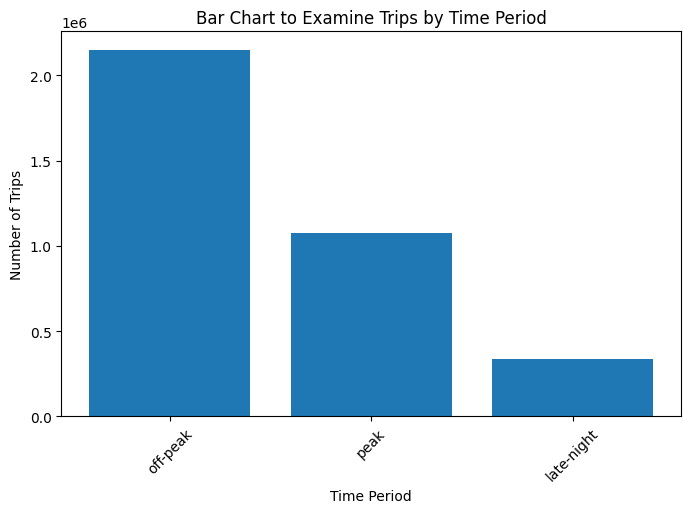

In [82]:
plt.figure(figsize=(8,5))
plt.bar(time_period_demand['time_period'], time_period_demand['trip_count'])
plt.title('Bar Chart to Examine Trips by Time Period')
plt.xlabel('Time Period')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.show()

### Horizontal Bar Chart to examine The Overall Top 10 Pickup Zones

This chart depicts the top 10 yellow taxi pickup zones by trip count. The largest demand was recorded in the Upper East South Side and Upper East North Side, and seondary include midtown centre and JFK airport. The majority of the densely distributed zones are located within manhatten, validating the strong trend of significant taxi demand in concentrated CBDs.

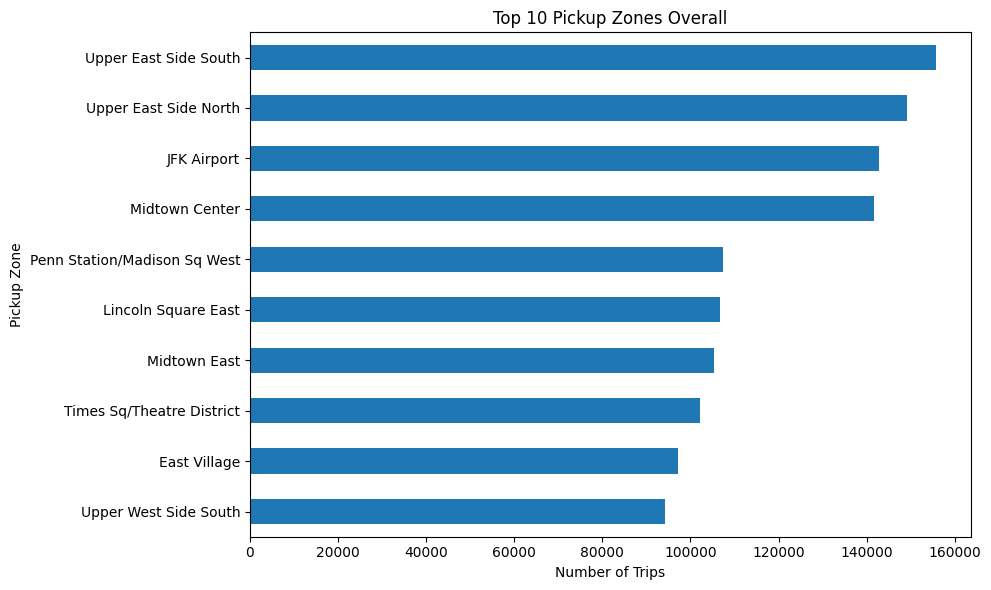

In [74]:
top_pickup_zones.sort_values("trip_count", ascending=True).plot(
    x="pickup_zone",
    y="trip_count",
    legend=False,
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.title("Top 10 Pickup Zones Overall")
plt.tight_layout()
plt.show()

### Grouped Bar Chart to to Examine Borrow Demand by Time Period

The grouped bar chart dictates that Manhattan experiences the largest amount of taxi demand within every time perod, primarily during peak and off-peak hours. Queens and Brooklyn depict moderate demand, whilst Staten Island, the Bronx, EWR and the unknown locations had significantly less trips. This highlights that taxi services should provide priority to manhattan due to urbanisation, but must also look towards monotior demand from outer boroughs.

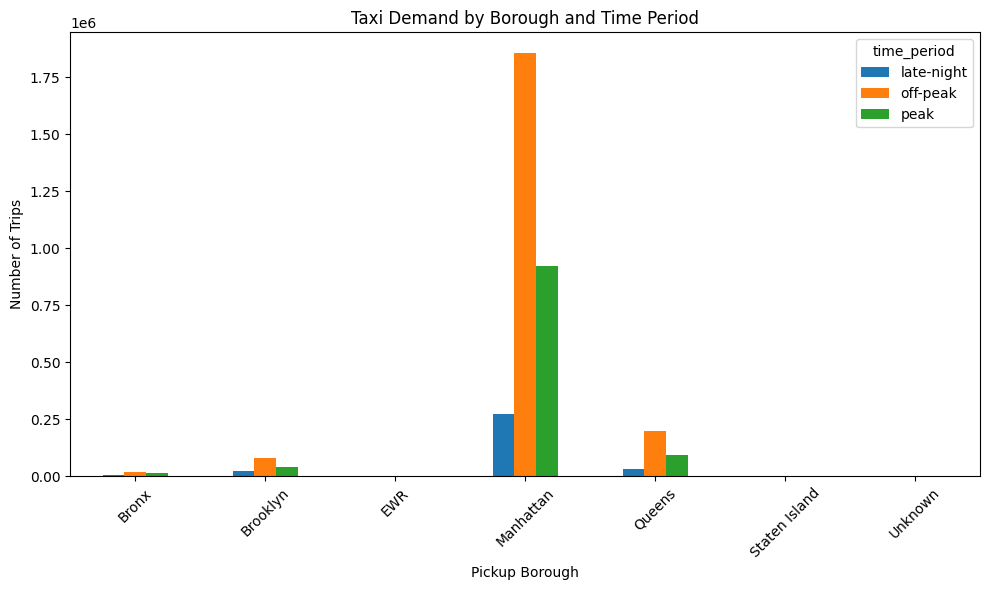

In [81]:
pivot_df = borough_time_period_demand_df.pivot(
    index="pickup_borough",
    columns="time_period",
    values="trip_count"
)

pivot_df.plot(kind="bar", figsize=(10, 6))

plt.title("Taxi Demand by Borough and Time Period")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 1.6 Privact, Governance, Ethics and Limitations

This data analyais project was operated on the public NYC taxi trip data, though the data may need to managed delicately as it stores mobility-related content including trip times, pickup and dropoff locationIDs. Location and Trip-level time data can lead to the discovery irregular trends if analysed inaccurately.

To mitigate this issue, the pipeline implements a data minimisation method. Columns necessary to aid in answering the business question were maintained such as trip_distance, fare_amount and location IDs. Columns that weren't useful to support answering the business question were discarded.

The analysis ensures that trips are collectively examined in detail, rather than being individual. This is projected through the several SQL queries and charts which centralise the data via time period and taxi zone. Conseuntly, this suppors taxy flow planning, whilst disregarding issuing statements conducted by external drivers.

The data cleaning process ensured that the results and overall datasets were transformed into more reliable data. Duplicate rows, impossible fares, invalid timestamps and impossible distances were effectively discarded to prevent a variety of issues such as demand inflation from rising. Invalid passenger values instead of being discarded were converted into unknown values, therefore staying inside the dataset as it didn't affect the primary purpose of answering the business question.

Limitations within the dataset are still prevalent. The analysis only utilises the dataset for yellow taxi data during January 2026, though the final results won't overly represent demand in neighbouring months or other modes of transport. Furthermore, results from this analysis should only stay withn the scope of yellow taxi demand data only.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')